## Non-linear regression with feedforward networks

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt

In [2]:
key = jr.key(42)
key_x, key_W1, key_b1, key_W2, key_b2 = jr.split(key, 5)

### Data Generation

Synthetic data from the function:

$$y = 2 \sin(3x) - 3 \cos(7x) $$

In [3]:
def f(x):
    return 2*jnp.sin(3*x)  - 3*jnp.cos(7*x)

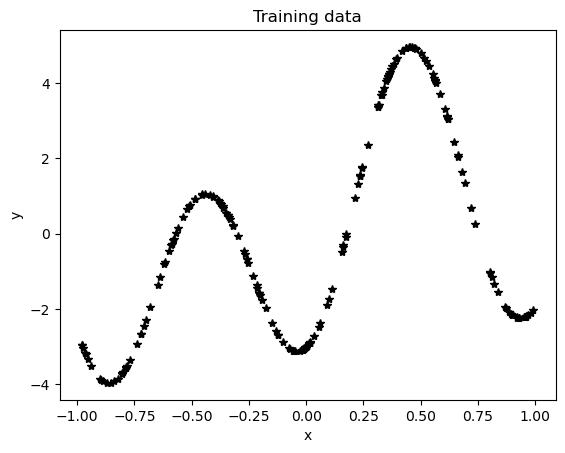

In [4]:
a = -1 # lower limit x
b = 1 # higher limit x
n_samples = 200 # data point
sigma_e = 0.1 # noise std
x_train = a + jr.uniform(key_x, shape=(n_samples, 1))*(b - a);
x_train = x_train.reshape(-1, 1)
y_train = f(x_train)

plt.plot(x_train, y_train, "*k")
plt.title("Training data")
plt.xlabel("x")
plt.ylabel("y");

Always good to check data types and shapes. Saves like 80% of debugging time!

In [5]:
x_train.shape, y_train.shape

((200, 1), (200, 1))

In [6]:
x_train.dtype, y_train.dtype

(dtype('float32'), dtype('float32'))

### Feed-formward Neural Network Model Definition

Define the feedforward neural network with one hidden layer:

  $$y = W_2 \tanh (W_1 x + b_1) + b_2 $$

The parameters to be tuned are:

  $$p = \mathrm{vec}(W_1, b_1, W_2, b_2)$$
  $$ W_1 \in \mathbb{R}^{n_h \times n_x}, b_1 \in \mathbb{R}^{n_h}, 
W_2 \in \mathbb{R}^{n_y \times n_h}, b_2 \in \mathbb{R}^{n_y}.$$

In [7]:
# Initialize all parameters and organize them in a dictionary

nx = 1; ny = 1; nh = 16
params = {
  "W1": jr.normal(key_W1, shape=(nh, nx)),
  "b1": jr.normal(key_b1, shape=(nh,)),
  "W2": jr.normal(key_W2, shape=(ny, nh)),
  "b2": jr.normal(key_b2, shape=(ny,)),
}

params

{'W1': Array([[ 0.60576403],
        [ 0.7990441 ],
        [-0.908927  ],
        [-0.63525754],
        [-1.2226585 ],
        [-0.83226097],
        [-0.47417238],
        [-1.2504351 ],
        [-0.17678244],
        [-0.04917514],
        [-0.41177532],
        [-0.39363015],
        [ 1.3116323 ],
        [ 0.21555556],
        [ 0.41164538],
        [-0.28955024]], dtype=float32),
 'b1': Array([ 0.4323065 ,  0.5872638 , -1.1416743 , -0.37379906, -0.19910173,
        -1.7271094 , -1.8330271 , -0.46168378, -0.03195509, -1.7773895 ,
         1.4154723 ,  0.15855731,  1.0224432 , -0.27967322, -0.86966294,
        -0.9404852 ], dtype=float32),
 'W2': Array([[-0.2818947 , -1.367489  , -1.6350379 ,  0.30999872, -0.3844943 ,
          0.20303132,  0.1672151 , -0.87490034,  0.06019142, -0.49940696,
          0.7585605 , -1.6018335 ,  0.27223408, -1.0746151 ,  1.1858177 ,
          0.558432  ]], dtype=float32),
 'b2': Array([0.6549178], dtype=float32)}

In [8]:
# Define the neural network as a function of parameters and inputs

def nn(p, x):
    h = jnp.tanh(p["W1"] @ x + p["b1"])
    y = p["W2"] @ h + p["b2"]
    return y

In [9]:
# Run the neural network with initial parameters and a sample input

nn(params, x_train[10])

Array([1.5116649], dtype=float32)

In [10]:
# The commented command fails because of shape mismatch. We need to vectorize the nn function
# nn(p_hat, x_train)

In [11]:
# Do nothing for first arg, expect a batch axis at the left (0th axis) for second arg
batched_nn = jax.vmap(nn, in_axes=(None, 0))

In [12]:
x_train.shape

(200, 1)

In [13]:
# The batched output also has a batch axis at the left (0th axis). Just what we want!
y = batched_nn(params, x_train)
y.shape

(200, 1)

In [14]:
# Check that it is correct, if you don't believe!
nn(params, x_train[10]), y[10]

(Array([1.5116649], dtype=float32), Array([1.5116649], dtype=float32))

### Model Training


#### Loss Function and Gradient definition
From now on, it's more or less like what we did for linear regression! 

In [15]:
def loss_fn(p, y, x):
    ym = batched_nn(p, x)
    loss = jnp.mean((y - ym) ** 2)
    return loss

# the function loss_grad_fn will return both loss and gradient of the loss
loss_grad_fn = jax.value_and_grad(loss_fn, 0)

# Important performance trick: just-in-time compilation for this compute-intensive part!
loss_grad_fn = jax.jit(loss_grad_fn)

In [16]:
loss_grad_fn(params, y_train, x_train)

(Array(8.191614, dtype=float32),
 {'W1': Array([[ 0.2139632 ],
         [ 1.1391872 ],
         [ 1.194308  ],
         [-0.2304454 ],
         [ 0.21366106],
         [-0.06802016],
         [-0.02712739],
         [ 0.6121687 ],
         [-0.0265999 ],
         [ 0.02947719],
         [ 0.09250788],
         [ 0.46931845],
         [-0.23199867],
         [ 0.28123924],
         [ 0.17508736],
         [-0.24751122]], dtype=float32),
  'W2': Array([[ 0.7253651 ,  0.8976965 , -1.7544472 , -0.5732916 ,  0.18293373,
          -2.3433988 , -2.477539  , -0.29266736, -0.00832098, -2.5071402 ,
           2.3557894 ,  0.5542563 ,  1.2461408 , -0.79461575, -1.8754516 ,
          -1.8615233 ]], dtype=float32),
  'b1': Array([-0.62096965, -2.766383  , -2.212212  ,  0.6925952 , -0.70631444,
          0.1160558 ,  0.05764761, -1.6566526 ,  0.15768676, -0.14585862,
          0.42188248, -3.7965527 ,  0.43861058, -2.547222  ,  1.5038776 ,
          0.74429154], dtype=float32),
  'b2': Array([2.6574

In [17]:
params_init = params # save it just for reference

In [18]:
lr = 1e-2
iters = 1000

# Setup optimizer
optimizer = optax.adam(learning_rate=lr)
opt_state = optimizer.init(params)

# Training loop
LOSS = []
for iter in range(iters):
    loss_val, grads = loss_grad_fn(params, y_train, x_train)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    LOSS.append(loss_val)

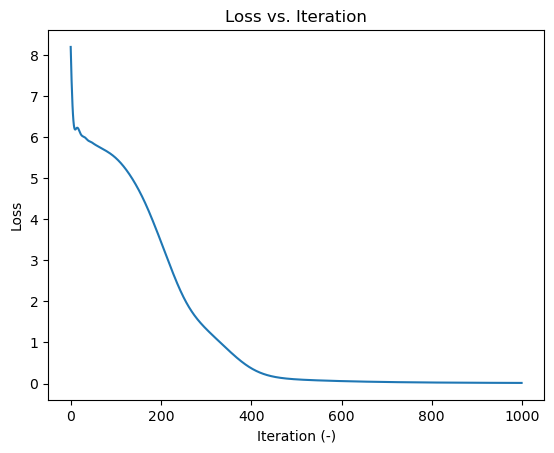

In [19]:
plt.figure()
plt.title("Loss vs. Iteration")
plt.plot(LOSS)
plt.xlabel("Iteration (-)")
plt.ylabel("Loss");

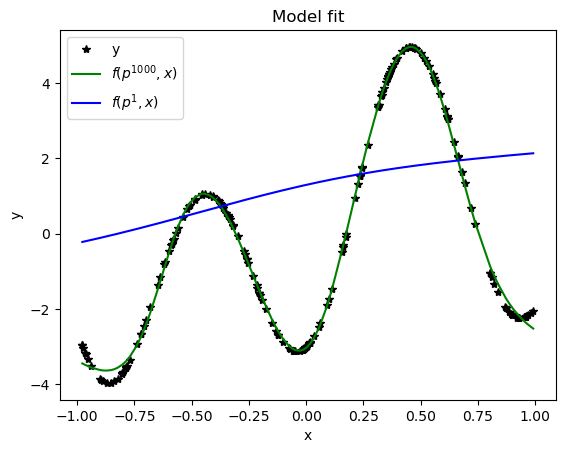

In [20]:
x_train_srt = jnp.sort(x_train, axis=0)
plt.figure()
plt.title("Model fit")
plt.plot(x_train, y_train, "k*", label="y")
plt.plot(x_train_srt, batched_nn(params, x_train_srt), "g", label=f"$f(p^{{{iters}}}, x)$")
plt.plot(x_train_srt, batched_nn(params_init, x_train_srt), "b", label="$f(p^{1}, x)$")
plt.xlabel("x")
plt.ylabel("y")
plt.legend();